In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.initializers import HeNormal
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.pipeline import Pipeline
import joblib

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df_G1P1 = pd.read_csv("Plant_1_Generation_Data.csv")
df_W1P1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")
df_G2P2 = pd.read_csv("Plant_2_Generation_Data.csv")
df_W2P2 = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

In [3]:
df_G1P1.rename(columns={'DATE_TIME       ':'DATE_TIME'}, inplace=True)
df_G2P2.rename(columns={'DATE_TIME          ':'DATE_TIME'}, inplace=True)
df_W1P1.rename(columns={'DATE_TIME          ':'DATE_TIME'}, inplace=True)

In [4]:
df_G1P1['DATE_TIME'] = pd.to_datetime(df_G1P1['DATE_TIME'])
df_G2P2['DATE_TIME'] = pd.to_datetime(df_G2P2['DATE_TIME'])
df_W1P1['DATE_TIME'] = pd.to_datetime(df_W1P1['DATE_TIME'])
df_W2P2['DATE_TIME'] = pd.to_datetime(df_W2P2['DATE_TIME'])

D:\Temp\ipykernel_4404\3549955327.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_G1P1['DATE_TIME'] = pd.to_datetime(df_G1P1['DATE_TIME'])


In [5]:
generation = pd.concat([df_G1P1,df_G2P2], ignore_index=True)
weather = pd.concat([df_W1P1,df_W2P2], ignore_index=True)

In [6]:
generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

In [7]:
print(generation.columns.tolist())
print(weather.columns.tolist())

['DATE_TIME', ' PLANT_ID', ' SOURCE_KEY     ', ' DC_POWER      ', ' AC_POWER      ', ' DAILY_YIELD   ', ' TOTAL_YIELD', ' DC_POWER              ', ' AC_POWER              ', ' DAILY_YIELD            ']
['DATE_TIME', ' PLANT_ID', ' SOURCE_KEY     ', ' AMBIENT_TEMPERATURE', ' MODULE_TEMPERATURE', ' IRRADIATION', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [8]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()                 # remove start/end spaces
        .str.replace(' ', '_')       # replace spaces with underscore
        .str.replace('__+', '_', regex=True)  # remove multiple underscores
    )
    return df

df_G1P1 = clean_columns(df_G1P1)
df_G2P2 = clean_columns(df_G2P2)
df_W1P1 = clean_columns(df_W1P1)
df_W2P2 = clean_columns(df_W2P2)

In [9]:
print(df_G1P1.columns)
print(df_W1P1.columns)

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')


In [10]:
g1 = df_G1P1
g2 = df_G2P2

w1 = df_W1P1
w2 = df_W2P2

generation = pd.concat([g1, g2], ignore_index=True)
weather = pd.concat([w1, w2], ignore_index=True)

In [11]:
df = pd.merge(
    generation,
    weather,
    how='inner',
    on=['DATE_TIME','PLANT_ID']
)

In [12]:
print(df.columns)
print(df.shape)

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')
(136472, 11)


In [13]:
plant_df = df.groupby('DATE_TIME').agg({
    'AC_POWER':'sum',
    'IRRADIATION':'mean',
    'AMBIENT_TEMPERATURE':'mean',
    'MODULE_TEMPERATURE':'mean'
}).reset_index()

In [14]:
print(plant_df.shape)
plant_df.head()

(3262, 5)


,DATE_TIME,AC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
0,2020-05-15 00:00:00,0.0,0.0,26.115708,23.984768
1,2020-05-15 00:15:00,0.0,0.0,26.003586,23.611073
2,2020-05-15 00:30:00,0.0,0.0,25.829210,23.531135
3,2020-05-15 00:45:00,0.0,0.0,25.692598,23.414716
4,2020-05-15 01:00:00,0.0,0.0,25.608837,23.626817


In [15]:
plant_df = plant_df[plant_df['IRRADIATION'] > 0]

In [16]:
plant_df['hour'] = plant_df['DATE_TIME'].dt.hour
plant_df['day'] = plant_df['DATE_TIME'].dt.day
plant_df['month'] = plant_df['DATE_TIME'].dt.month

In [17]:
plant_df.columns
plant_df.head()

,DATE_TIME,AC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,hour,day,month
23,2020-05-15 05:45:00,0.000000,0.001873,24.520499,23.449700,5,15,5
24,2020-05-15 06:00:00,411.362500,0.009507,24.423225,23.163743,6,15,5
25,2020-05-15 06:15:00,1160.316310,0.021645,24.396520,23.378112,6,15,5
26,2020-05-15 06:30:00,2723.750833,0.045923,24.381527,23.721084,6,15,5
27,2020-05-15 06:45:00,6164.106786,0.099445,24.633618,25.094553,6,15,5


In [18]:
df.fillna(0,inplace=True)

In [19]:
df.isnull().sum()

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

In [20]:
#Removing the extra white space from column name
df.columns = df.columns.str.strip()

In [21]:
#Rename the column names having same names

cols = pd.Series(df.columns)

for i in range(len(cols)):
    if cols[i] in cols[:i].values:
        count = 1
        new_col = cols[i] + "_" + str(count)

        while new_col in cols[:i].values:
            count += 1
            new_col = cols[i] + "_" + str(count)

        cols[i] = new_col

df.columns = cols

In [22]:
df.columns

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')

In [23]:
df.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,136472,1.364720e+05,136472.000000,136472.000000,136472.000000,1.364720e+05,136472.000000,136472.000000,136472.000000
mean,2020-06-01 09:22:57.605662464,4.135497e+06,1708.373962,274.790259,3295.366192,3.303916e+08,26.763066,31.920744,0.230767
min,2020-05-15 00:00:00,4.135001e+06,0.000000,0.000000,0.000000,0.000000e+00,20.398505,18.140415,0.000000
25%,2020-05-23 23:00:00,4.135001e+06,0.000000,0.000000,28.285714,6.520020e+06,23.637604,22.411698,0.000000
50%,2020-06-01 18:45:00,4.135001e+06,5.993333,3.493095,2834.642857,7.269333e+06,25.908122,26.413755,0.026213
75%,2020-06-09 21:45:00,4.136001e+06,1155.595000,532.568571,5992.000000,2.826096e+08,29.266583,40.778583,0.442961
max,2020-06-17 23:45:00,4.136001e+06,14471.125000,1410.950000,9873.000000,2.247916e+09,39.181638,66.635953,1.221652
std,NaN,4.999863e+02,3222.079306,380.180214,3035.313217,6.085769e+08,3.897340,11.803674,0.305652


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136472 entries, 0 to 136471
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            136472 non-null  datetime64[ns]
 1   PLANT_ID             136472 non-null  int64         
 2   SOURCE_KEY_x         136472 non-null  object        
 3   DC_POWER             136472 non-null  float64       
 4   AC_POWER             136472 non-null  float64       
 5   DAILY_YIELD          136472 non-null  float64       
 6   TOTAL_YIELD          136472 non-null  float64       
 7   SOURCE_KEY_y         136472 non-null  object        
 8   AMBIENT_TEMPERATURE  136472 non-null  float64       
 9   MODULE_TEMPERATURE   136472 non-null  float64       
 10  IRRADIATION          136472 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 11.5+ MB


In [25]:
df['hour'] = df['DATE_TIME'].dt.hour
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month

In [26]:
df.columns

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'day', 'month'],
      dtype='object')

In [27]:
df.shape

(136472, 14)

In [28]:
df

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,day,month
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136467,2020-06-17 23:45:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,4157.0,520758.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0,23,17,6
136468,2020-06-17 23:45:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,3931.0,121131356.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0,23,17,6
136469,2020-06-17 23:45:00,4136001,vOuJvMaM2sgwLmb,0.0,0.0,4322.0,2427691.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0,23,17,6
136470,2020-06-17 23:45:00,4136001,xMbIugepa2P7lBB,0.0,0.0,4218.0,106896394.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0,23,17,6


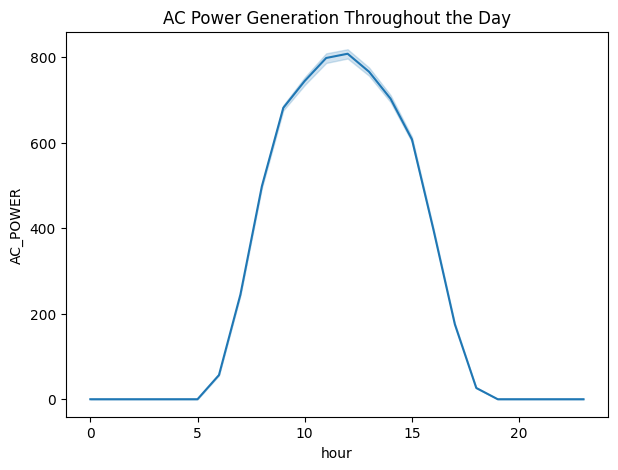

In [29]:
plt.figure(figsize=(7,5))
sns.lineplot(data=df, x="hour", y="AC_POWER")
plt.title("AC Power Generation Throughout the Day")
plt.show()

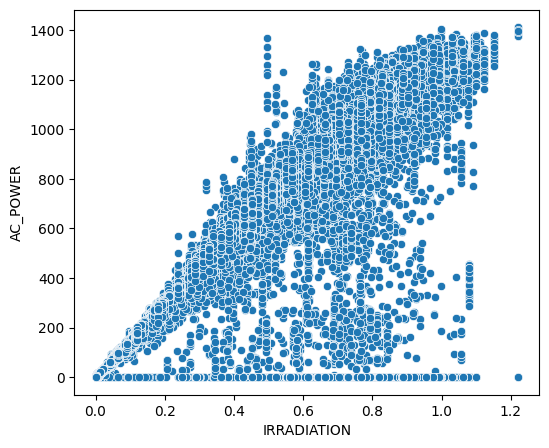

In [30]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="IRRADIATION", y="AC_POWER")
plt.show()

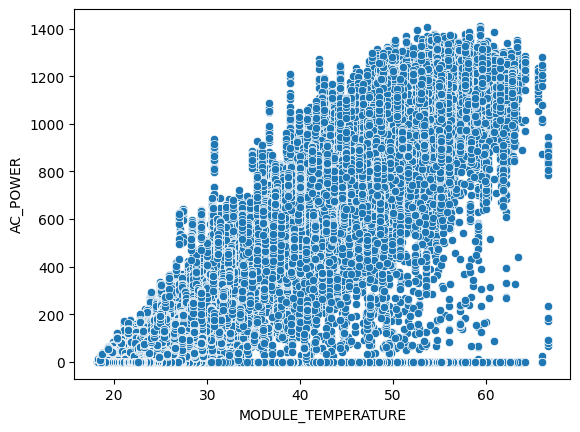

In [31]:
sns.scatterplot(data=df, x="MODULE_TEMPERATURE", y="AC_POWER")
plt.show()

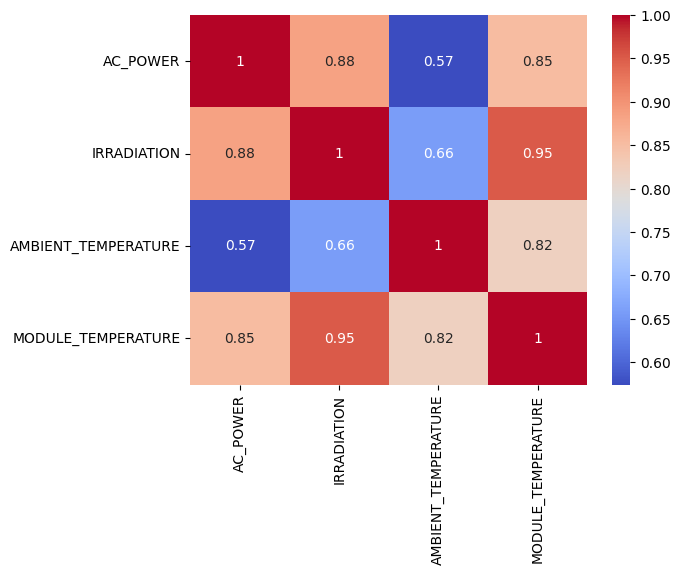

In [32]:
sns.heatmap(df[['AC_POWER','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']].corr(),
            annot=True, cmap="coolwarm")
plt.show()

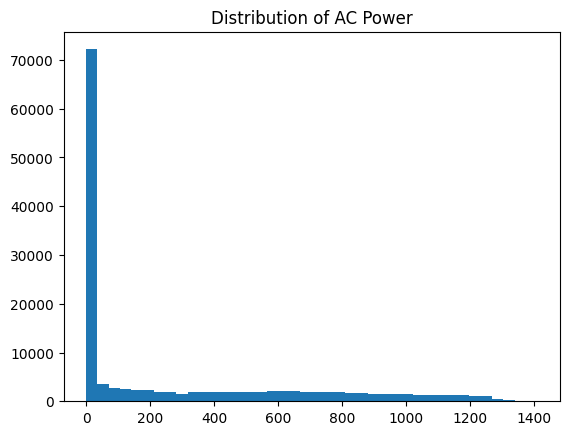

In [33]:
plt.hist(df["AC_POWER"], bins=40)
plt.title("Distribution of AC Power")
plt.show()

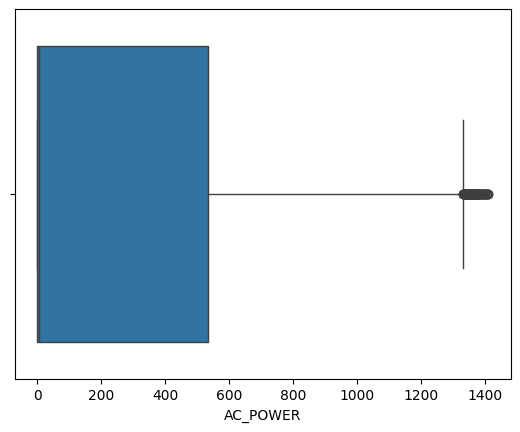

In [34]:
sns.boxplot(x=df["AC_POWER"])
plt.show()

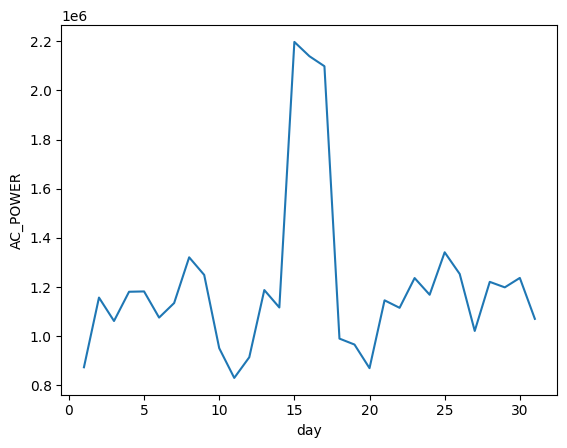

In [35]:
daily = df.groupby("day")["AC_POWER"].sum().reset_index()
sns.lineplot(data=daily, x="day", y="AC_POWER")
plt.show()

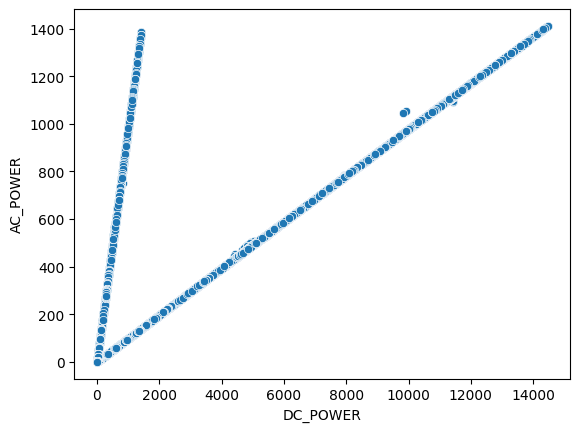

In [36]:
sns.scatterplot(data=df, x="DC_POWER", y="AC_POWER")
plt.show()

In [37]:
X = df.drop(['DATE_TIME','PLANT_ID','SOURCE_KEY_x','DC_POWER','DAILY_YIELD','TOTAL_YIELD','SOURCE_KEY_y','AC_POWER'],axis=1)
y = df['AC_POWER']

In [38]:
X

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,day,month
0,25.184316,22.857507,0.0,0,15,5
1,25.184316,22.857507,0.0,0,15,5
2,25.184316,22.857507,0.0,0,15,5
3,25.184316,22.857507,0.0,0,15,5
4,25.184316,22.857507,0.0,0,15,5
...,...,...,...,...,...,...
136467,23.202871,22.535908,0.0,23,17,6
136468,23.202871,22.535908,0.0,23,17,6
136469,23.202871,22.535908,0.0,23,17,6
136470,23.202871,22.535908,0.0,23,17,6


In [39]:
y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
136467    0.0
136468    0.0
136469    0.0
136470    0.0
136471    0.0
Name: AC_POWER, Length: 136472, dtype: float64

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
X_train.shape

(109177, 6)

In [42]:
X_test.shape

(27295, 6)

## Linear Regression

In [43]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr_train = lr.predict(X_train)
mse_lr = mean_squared_error(y_test,y_pred_lr)
mae_lr = mean_absolute_error(y_test,y_pred_lr)
r2_lr = r2_score(y_test,y_pred_lr)
r2_lr_train = r2_score(y_train,y_pred_lr_train)
print("Mean Squared Error:",mse_lr)
print("Mean Absolute Error:",mae_lr)
print("Test R2 Score:",r2_lr)
print("Train R2 Score:",r2_lr_train)

Mean Squared Error: 30503.641338693942
Mean Absolute Error: 79.86866295492158
Test R2 Score: 0.7896092570949185
Train R2 Score: 0.7893946249625098


### Decision Tree Regressor

In [93]:
params = {
    "criterion":["squared_error","friedman_mse","absolute_error"],
    "splitter":["best","random"],
    "max_depth":[4,5,6,7,8],
    "min_samples_split":[4,5,6,7,8],
    "min_samples_leaf":[4,5,6,7,8],
    "max_features":["auto","sqrt","log2"],
    "max_leaf_nodes":[4,5,6,7,]
}

dt = DecisionTreeRegressor()
grid = RandomizedSearchCV(dt,param_distributions=params,scoring="r2",cv=5,n_jobs=-1)
grid.fit(X_train,y_train)

y_pred_dt = grid.predict(X_test)
y_pred_dt_train = grid.predict(X_train)

mse_dt = mean_squared_error(y_test,y_pred_dt)
mae_dt = mean_absolute_error(y_test,y_pred_dt)
r2_dt = r2_score(y_test,y_pred_dt)
r2_dt_train = r2_score(y_train,y_pred_dt_train)

print("Mean Squared Error:",mse_dt)
print("Mean Absolute Error:",mae_dt)
print("Test R2 Score:",r2_dt)
print("Train R2 Score:",r2_dt_train)

Mean Squared Error: 30276.32668229762
Mean Absolute Error: 81.72788983176
Test R2 Score: 0.7911770994027079
Train R2 Score: 0.7910011705586686


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

## XGBoost

In [44]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(objective="reg:squarederror", random_state=42))
])

param_grid = {
    "model__n_estimators": [100,200,300,400],
    "model__max_depth": [3,4,5,6,7],
    "model__learning_rate": [0.01,0.05,0.1],
    "model__subsample": [0.7,0.8,1],
    "model__colsample_bytree": [0.7,0.8,1]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
y_pred_xgb = search.predict(X_test)
y_pred_xgb_train = search.predict(X_train)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
print("Mean Squared Error:", mse_xgb)
print("Mean Absolute Error:", mae_xgb)
print("Test R2 Score:", r2_xgb)
print("Train R2 Score:", r2_xgb_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mean Squared Error: 22049.964099752444
Mean Absolute Error: 50.85851572399978
Test R2 Score: 0.8479162446060965
Train R2 Score: 0.8609581596019156


## SVM

In [95]:
svr = SVR()
svr.fit(X_train,y_train)
y_pred_svr = svr.predict(X_test)
y_pred_svr_train = svr.predict(X_train)
mse_svr = mean_squared_error(y_test,y_pred_svr)
mae_svr = mean_absolute_error(y_test,y_pred_svr)
r2_svr = r2_score(y_test,y_pred_svr)
r2_svr_train = r2_score(y_train,y_pred_svr_train)
print("Mean Squared Error:",mse_svr)
print("Mean Absolute Error:",mae_svr)
print("Test R2 Score:",r2_svr)
print("Train R2 Score:",r2_svr_train)

Mean Squared Error: 33535.56035847504
Mean Absolute Error: 81.1752427526169
Test R2 Score: 0.7686974030668345
Train R2 Score: 0.766315189880629


## ANN

In [96]:
model = Sequential()
model.add(Dense(128,activation='relu',kernel_initializer = 'he_normal',input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dense(64,activation='relu',kernel_initializer = 'he_normal'))
model.add(BatchNormalization())
model.add(Dense(64,activation='relu',kernel_initializer = 'he_normal'))
model.add(BatchNormalization())
model.add(Dense(32,activation='relu',kernel_initializer = 'he_normal'))
model.add(BatchNormalization())
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [98]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,577 (64.75 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 576 (2.25 KB)

In [99]:
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.2)

Epoch 1/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 107198.0156 - mae: 191.5191 - val_loss: 30189.3008 - val_mae: 95.4657
Epoch 2/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 31054.2695 - mae: 99.1232 - val_loss: 31115.2539 - val_mae: 107.8997
Epoch 3/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 29763.7949 - mae: 98.2773 - val_loss: 29227.5742 - val_mae: 98.4060
Epoch 4/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 29337.0762 - mae: 98.1538 - val_loss: 29317.9609 - val_mae: 102.7666
Epoch 5/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 28761.8223 - mae: 96.5190 - val_loss: 26232.7168 - val_mae: 75.7678
Epoch 6/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 28711.5684 - mae: 96.0099 - val_loss: 26872.5820 - val_mae: 88.8561
Epoch 7/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 28603.6543 - mae: 95.5215 - val_loss: 25226.2344 - val_mae: 61.9957
Epoch 8/100
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 28534.4629 -

In [100]:
y_pred_ann = model.predict(X_test)

853/853 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [101]:
r2_ann = r2_score(y_test,y_pred_ann)
print("R2 Score:",r2_ann)

R2 Score: 0.8378092856388424


In [102]:
y_pred_ann_train = model.predict(X_train)

3412/3412 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [104]:
r2_ann_train = r2_score(y_train,y_pred_ann_train)
print("R2 Score:",r2_ann)

R2 Score: 0.8378092856388424


In [105]:
mse_ann = mean_squared_error(y_test, y_pred_ann)
mae_ann = mean_absolute_error(y_test, y_pred_ann)

print("MSE ANN:", mse_ann)
print("MAE ANN:", mae_ann)

MSE ANN: 23515.328246030993
MAE ANN: 61.80030758830794


In [106]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor", "XGBoost", "SVM", "ANN"],
    "MSE": [mse_lr, mse_dt, mse_xgb, mse_svr, mse_ann],
    "MAE" : [mae_lr,mae_dt,mae_xgb,mae_svr,mae_ann],
    "R2 Score": [r2_lr, r2_dt, r2_xgb, r2_svr, r2_ann],
    "Train R2 Score": [r2_lr_train, r2_dt_train, r2_xgb_train, r2_svr_train, r2_ann_train],
})

In [107]:
results

,Model,MSE,MAE,R2 Score,Train R2 Score
0,Linear Regression,30503.641339,79.868663,0.789609,0.789395
1,Decision Tree Regressor,30276.326682,81.727890,0.791177,0.791001
2,XGBoost,21982.327036,52.620805,0.848383,0.854200
3,SVM,33535.560358,81.175243,0.768697,0.766315
4,ANN,23515.328246,61.800308,0.837809,0.839755


In [108]:
joblib.dump(model,"solar_model.pkl")

['solar_model.pkl']

In [110]:
model_final = joblib.load("/content/drive/MyDrive/DEEP Learning AAI/Project/solar_model.pkl")